# RFM Segmentation Modeling

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.3f}'.format)

data_path = os.path.join('..', 'data', '03_featured', 'featured_retail.csv')
df = pd.read_csv(data_path)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (5939, 11)
Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'recency_score', 'frequency_score', 'monetary_score', 'r_f_score', 'segment', 'return_ratio', 'avg_order_value']


,customer_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,r_f_score,segment,return_ratio,avg_order_value
0,12346,325,17,-51.740,2,5,1,25,cant_lose,1.001,-3.044
1,12347,1,8,"4,921.530",5,4,5,54,champions,0.000,615.191
2,12348,74,5,"2,019.400",3,3,4,33,need_attention,0.000,403.880
3,12349,18,5,"4,404.540",4,3,5,43,potential_loyalists,0.005,880.908
4,12350,309,1,334.400,2,1,2,21,hibernating,0.000,334.400


## 1) Core RFM Features

In [ ]:
rfm_cols = ['recency', 'frequency', 'monetary']
missing_cols = [c for c in rfm_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required RFM columns: {missing_cols}')

rfm = df[['customer_id'] + rfm_cols].copy() if 'customer_id' in df.columns else df[rfm_cols].copy()
rfm = rfm.dropna(subset=rfm_cols).copy()

valid_mask = (rfm['frequency'] >= 0) & (rfm['monetary'] > -1)
dropped_rows = int((~valid_mask).sum())
if dropped_rows:
    print(f'Dropped {dropped_rows} rows with invalid values for log transform.')
rfm = rfm.loc[valid_mask].copy()

rfm_model = rfm.copy()
rfm_model['frequency'] = np.log1p(rfm_model['frequency'])
rfm_model['monetary'] = np.log1p(rfm_model['monetary'])

X = rfm_model[rfm_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Rows available for clustering: {len(rfm_model):,}')
rfm_model[rfm_cols].describe()

Dropped 81 rows with invalid values for log transform.
Rows available for clustering: 5,858


,recency,frequency,monetary
count,"5,858.000","5,858.000","5,858.000"
mean,196.695,1.667,6.769
std,207.929,0.866,1.430
min,0.000,0.693,0.000
25%,23.000,1.099,5.810
50%,91.000,1.609,6.737
75%,375.000,2.197,7.684
max,738.000,6.236,13.254


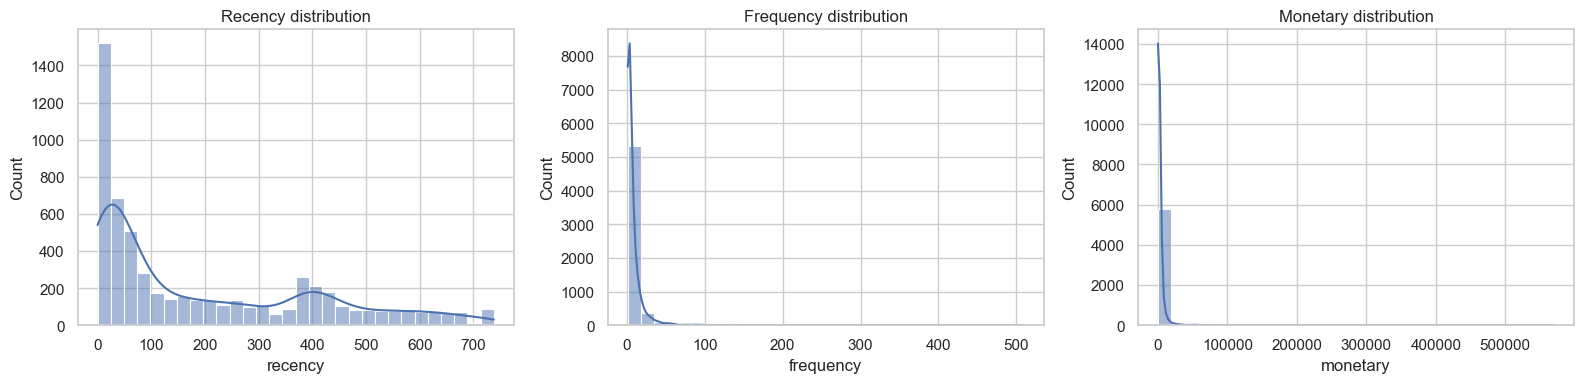

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, rfm_cols):
    sns.histplot(rfm[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'{col.title()} distribution')
plt.tight_layout()
plt.show()

## 2) Choose Number of Clusters (K)

Will be used:
- **Elbow method** (inertia) to see diminishing returns
- **Silhouette score** to assess separation quality

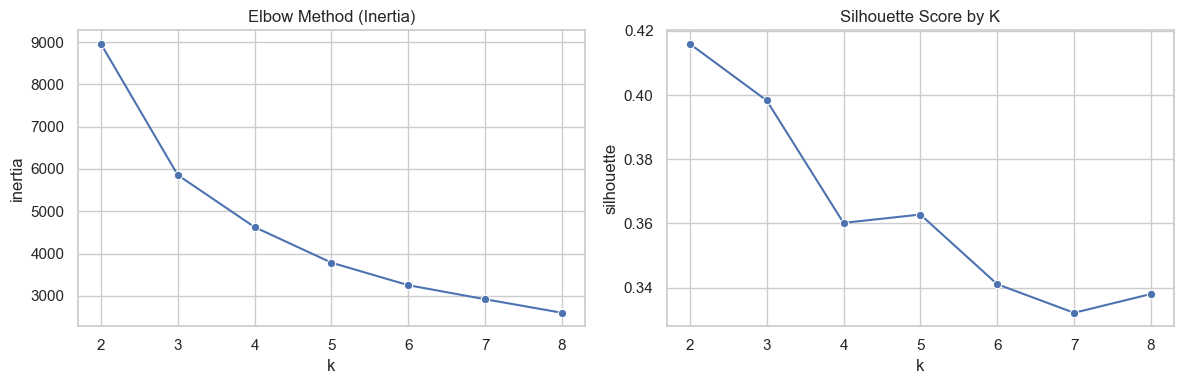

,k,inertia,silhouette
0,2,"8,960.397",0.416
1,3,"5,856.579",0.398
2,4,"4,624.879",0.360
3,5,"3,783.161",0.363
4,6,"3,250.765",0.341
5,7,"2,917.964",0.332
6,8,"2,597.585",0.338


In [4]:
k_values = list(range(2, 9))
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

k_eval = pd.DataFrame({
    'k': k_values,
    'inertia': inertias,
    'silhouette': silhouettes,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=k_eval, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow Method (Inertia)')

sns.lineplot(data=k_eval, x='k', y='silhouette', marker='o', ax=axes[1])
axes[1].set_title('Silhouette Score by K')

plt.tight_layout()
plt.show()

k_eval

In [ ]:
best_k = int(k_eval.loc[k_eval['silhouette'].idxmax(), 'k'])
if best_k < 3:
    best_k = 3

print(f'Selected K = {best_k}')

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm_model['cluster'] = kmeans.fit_predict(X_scaled)
rfm['cluster'] = rfm_model['cluster'].values

rfm[['customer_id', 'cluster']].head()

Selected K = 3


,customer_id,cluster
1,12347,0
2,12348,1
3,12349,0
4,12350,2
5,12351,2


## 3) Cluster Profiling and Interpretation

In [6]:
cluster_profile = (
    rfm.groupby('cluster')[rfm_cols]
    .agg(['count', 'mean', 'median'])
    .sort_index()
)

cluster_size = rfm['cluster'].value_counts().sort_index().rename('customers')
cluster_size_pct = (cluster_size / len(rfm) * 100).rename('share_pct')

cluster_overview = pd.concat([cluster_size, cluster_size_pct], axis=1)

display(cluster_overview)
display(cluster_profile)

,customers,share_pct
cluster,,
0,1714,29.259
1,2340,39.945
2,1804,30.795


recency                 frequency               monetary            \
          count    mean  median     count   mean median    count      mean   
cluster                                                                      
0          1714  56.709  24.000      1714 19.318 13.000     1714 7,910.034   
1          2340  89.249  58.000      2340  3.350  3.000     2340   814.938   
2          1804 469.069 436.000      1804  2.074  1.000     1804   508.799   

                   
           median  
cluster            
0       3,731.540  
1         689.595  
2         315.930

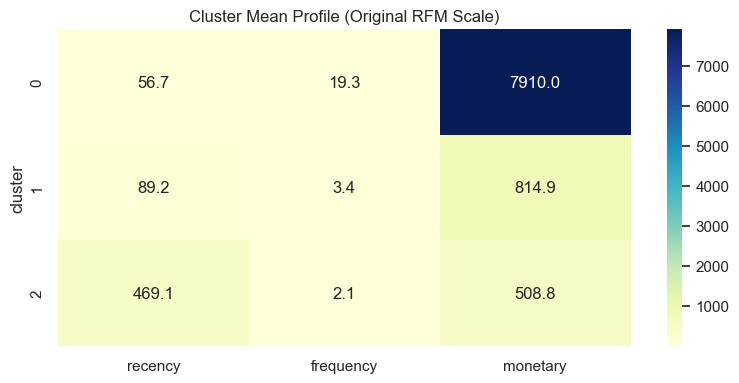

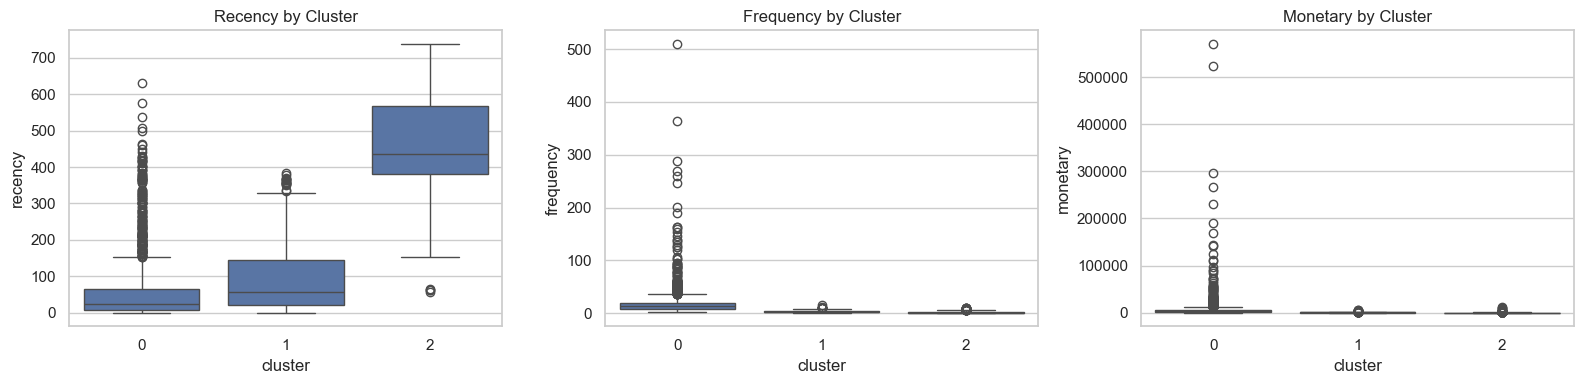

In [ ]:
cluster_means = rfm.groupby('cluster')[rfm_cols].mean().sort_index()

plt.figure(figsize=(8, 4))
sns.heatmap(cluster_means, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Cluster Mean Profile (Original RFM Scale)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, rfm_cols):
    sns.boxplot(data=rfm, x='cluster', y=col, ax=ax)
    ax.set_title(f'{col.title()} by Cluster')
plt.tight_layout()
plt.show()

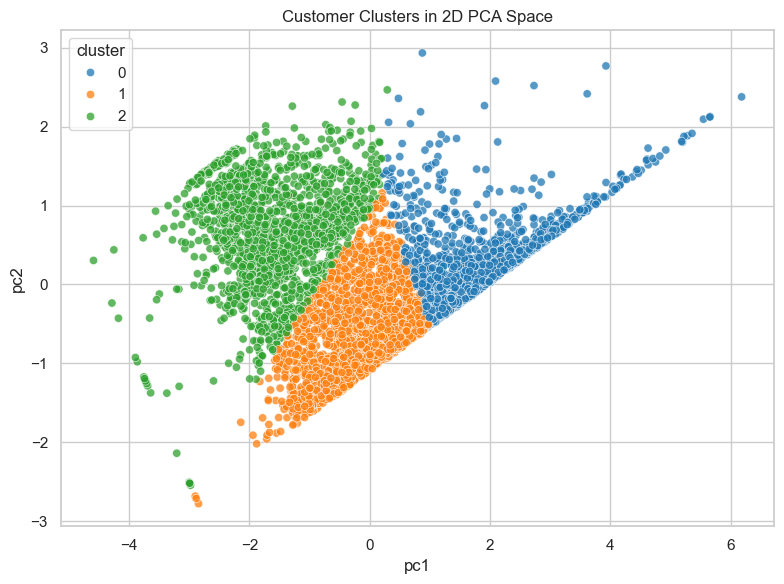

Explained variance (PC1 + PC2): 94.27%


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['pc1', 'pc2'])
pca_df['cluster'] = rfm['cluster'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='pc1', y='pc2', hue='cluster', palette='tab10', alpha=0.75)
plt.title('Customer Clusters in 2D PCA Space')
plt.tight_layout()
plt.show()

print(f'Explained variance (PC1 + PC2): {pca.explained_variance_ratio_.sum():.2%}')

In [ ]:
segment_map_base = rfm.groupby('cluster')[rfm_cols].mean().copy()
segment_map_base['value_rank'] = (
    segment_map_base['monetary'].rank(ascending=False, method='dense') +
    segment_map_base['frequency'].rank(ascending=False, method='dense') +
    segment_map_base['recency'].rank(ascending=True, method='dense')
)

segment_map_base = segment_map_base.sort_values('value_rank', ascending=True)
name_pool = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalists',
    'At Risk',
    'Hibernating',
    'Needs Attention',
    'Others'
]

name_map = {}
for i, cluster_id in enumerate(segment_map_base.index):
    name_map[cluster_id] = name_pool[i] if i < len(name_pool) else f'Cluster_{cluster_id}'

rfm['segment_name'] = rfm['cluster'].map(name_map)

segment_summary = (
    rfm.groupby(['cluster', 'segment_name'])[rfm_cols]
    .mean()
    .round(2)
    .sort_index()
)

segment_counts = (
    rfm.groupby(['cluster', 'segment_name'])
    .size()
    .rename('customers')
    .to_frame()
)

display(segment_counts)
display(segment_summary)

,,customers
cluster,segment_name,
0,Champions,1714
1,Loyal Customers,2340
2,Potential Loyalists,1804


,,recency,frequency,monetary
cluster,segment_name,,,
0,Champions,56.710,19.320,"7,910.030"
1,Loyal Customers,89.250,3.350,814.940
2,Potential Loyalists,469.070,2.070,508.800


In [ ]:
out_dir = os.path.join('..', 'data', '04_segmented')
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'customer_segments_kmeans.csv')

rfm.to_csv(out_path, index=False)
print(f'Saved segmentation output to: {out_path}')

Saved segmentation output to: ..\data\04_segmented\customer_segments_kmeans.csv
